# Copernicus DEM — quickstart (anonymous, no account)

Fetch **Copernicus DEM** coverage of the Nile Delta from the public AWS Open
Data bucket, then read + plot it with `pyramids`. No credentials, no SDK
login, no API key — the bucket is anonymous. `earthlens.dem` just hands you
the raw COGs; the cropping / mosaicking / hillshade is `pyramids`' job.

The delta spans eight 1° tiles, so this goes in two steps: one tile first, to
show what a single COG looks like, then the full eight-tile bbox mosaicked
into one continuous raster.


## Setup

`earthlens` provides the unified `EarthLens` entry point; `pyramids` reads the
downloaded COG; downloads go to a per-notebook temp directory.

In [1]:
import os
import tempfile
from pathlib import Path

from IPython.display import Image, display
from pyramids.dataset import Dataset
from pyramids.plot import ColorBar, ColorScaling

from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

from earthlens.core import EarthLens
from earthlens.dem import Catalog

# DEM tiles are large, so they land off the system drive; override with EARTHLENS_CACHE.
(Path(os.environ.get('EARTHLENS_CACHE', 'D:/earthlens-cache')) / 'dem').mkdir(parents=True, exist_ok=True)
download_root = Path(tempfile.mkdtemp(prefix='dem-quickstart-', dir=Path(os.environ.get('EARTHLENS_CACHE', 'D:/earthlens-cache')) / 'dem'))
print(f'downloads will land under: {download_root}')

# Shared class breaks so all three maps are directly comparable. Most of the
# delta sits in the first few metres, so the breaks crowd there.
ELEVATION_BREAKS = [-25, -2, 0, 2, 4, 6, 10, 20, 50, 200, 750]
# One spelling of the colour-bar label, shared by all three maps.
ELEVATION_LABEL = 'elevation (m, EGM2008)'
# The axis labels are shared for the same reason.
LON_LABEL = 'longitude (°E)'
LAT_LABEL = 'latitude (°N)'

downloads will land under: D:\earthlens-cache\dem\dem-quickstart-cr797a69


## The DEM catalog

Two datasets ship today — the ~30 m GLO-30 and the ~90 m GLO-90 grids.
Reading the catalog is offline.

In [2]:
catalog = Catalog()
for dataset_id in sorted(catalog.datasets):
    row = catalog.get_dataset(dataset_id)
    print(
        f'{row}\n                 bucket={row.bucket:22} token={row.resolution_token}'
    )

cop-dem-glo-30   bucket=copernicus-dem-30m     token=10 ≈30 m
cop-dem-glo-90   bucket=copernicus-dem-90m     token=30 ≈90 m


## Download one GLO-30 tile

The Copernicus DEM grid is 1° x 1° tiles keyed by their SW corner. The bbox
here (`lat=[30.2, 30.8]`, `lon=[31.2, 31.8]`) lies entirely inside the tile at
`(30 N, 31 E)`, so exactly one COG is returned.

That tile holds the delta's **south-eastern margin** — the flat farmland
south-east of the apex, running up against the eastern desert escarpment. It
is not the delta itself: the coastline, the Rosetta and Damietta branches and
the lagoons all sit outside it. The mosaic further down covers the whole thing.


In [3]:
single_out = download_root / 'delta_margin'
paths = EarthLens(
    data_source='dem',
    dataset='cop-dem-glo-30',
    lat_lim=[30.2, 30.8],
    lon_lim=[31.2, 31.8],
    path=single_out,
).download()

for path in paths:
    print(f'  {path.name}  ({path.stat().st_size / 1024**2:.1f} MB)')

dem/cop-dem-glo-30:   0%|          | 0/1 [00:00<?, ?tile/s]

dem/cop-dem-glo-30: 100%|██████████| 1/1 [00:01<00:00,  1.85s/tile]

dem/cop-dem-glo-30: 100%|██████████| 1/1 [00:01<00:00,  1.85s/tile]

  Copernicus_DSM_COG_10_N30_00_E031_00_DEM.tif  (47.2 MB)


## Read the tile back with pyramids

The returned COG carries a WGS84 CRS and one elevation band (metres above
the EGM2008 geoid). Read it into a `pyramids.Dataset` and plot the raw
elevation.

EPSG        : 4326
shape (y, x): 3600 x 3600
pixel size  : 0.0002777777777777778
no-data     : (None,)


Text(90.95722222222211, 0.5, 'latitude (°N)')

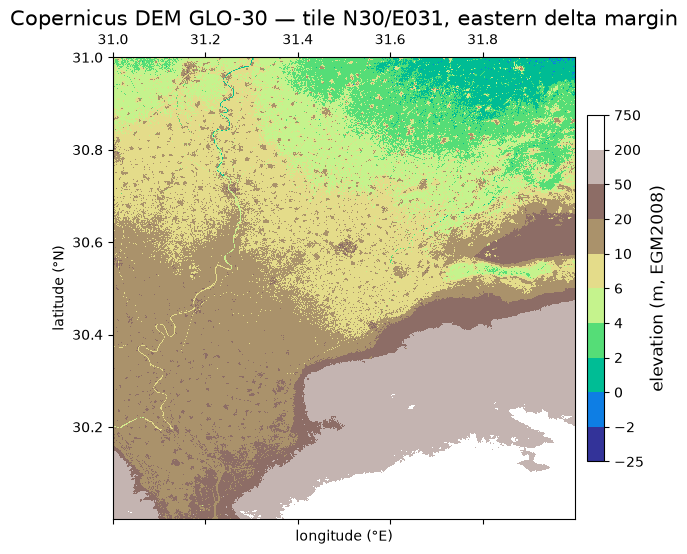

In [4]:
dem = Dataset.read_file(paths[0])
print(f'EPSG        : {dem.epsg}')
print(f'shape (y, x): {dem.rows} x {dem.columns}')
print(f'pixel size  : {dem.cell_size}')
print(f'no-data     : {dem.no_data_value}')

glyph = dem.plot(
    cmap='terrain',
    color=ColorScaling.boundary(bounds=ELEVATION_BREAKS),
    colorbar=ColorBar(label=ELEVATION_LABEL),
    title='Copernicus DEM GLO-30 — tile N30/E031, eastern delta margin',
)
glyph.ax.set_xlabel(LON_LABEL)
glyph.ax.set_ylabel(LAT_LABEL)

## Crop the tile to the exact bbox

`earthlens` returns the whole 1° tile. To keep only the bbox pixels, hand
the raster to `pyramids.Dataset.crop` with the bbox in `[west, south, east,
north]` order.

cropped shape (y, x): 2161 x 2161


Text(90.95722222222211, 0.5, 'latitude (°N)')

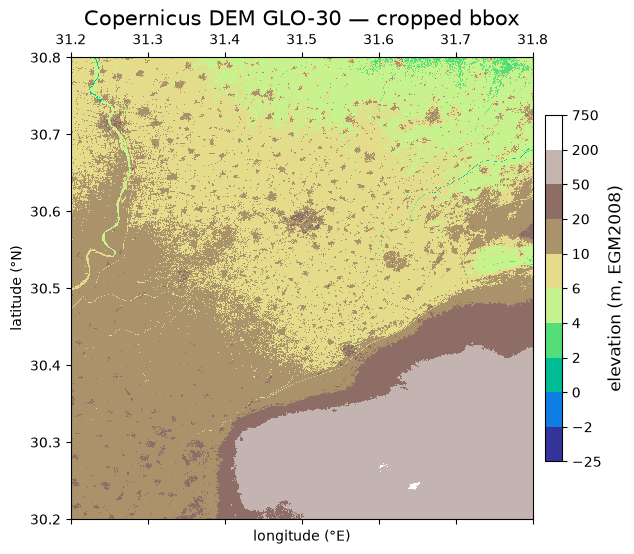

In [5]:
cropped = dem.crop(bbox=(31.2, 30.2, 31.8, 30.8), epsg=4326)
print(f'cropped shape (y, x): {cropped.rows} x {cropped.columns}')

glyph = cropped.plot(
    cmap='terrain',
    color=ColorScaling.boundary(bounds=ELEVATION_BREAKS),
    colorbar=ColorBar(label=ELEVATION_LABEL),
    title='Copernicus DEM GLO-30 — cropped bbox',
)
glyph.ax.set_xlabel(LON_LABEL)
glyph.ax.set_ylabel(LAT_LABEL)

## The whole delta — multi-tile bbox and mosaic

A wider bbox spans several tiles — `earthlens` returns one COG per
intersected tile in row-major order, and
`pyramids.dataset.merge.merge_rasters` composites them into one continuous
raster.

The Nile Delta runs from the apex at Cairo (~30.0 N) to the Mediterranean
(~31.5 N), and from the Rosetta branch (~29.8 E) east to Port Said (~32.4 E).
That bbox intersects **eight** tiles. GLO-90 is used here rather than GLO-30:
at 90 m the eight tiles are ~40 MB instead of ~380 MB, which is plenty to see
the delta's shape.

`merge_rasters` defaults to `no_data_value="0"`, which is wrong for a DEM: the
delta's water surfaces and its dead-flat farmland sit at exactly 0 m, so the
default masks nearly half the scene — the lagoons, the coast and the
sea-level parts of the delta all punch out as holes. Passing a sentinel the
data cannot contain keeps every real 0 m cell.

A linear colour ramp is useless here. Sixty percent of the delta lies below 10 m
while the flanking desert reaches 744 m, so a straight scale spends almost all
its colour on the margins and renders the delta as one flat wash. Explicit class
breaks — `ColorScaling.boundary` — concentrated in the first few metres
give the delta real contrast, and put a labelled tick on every break instead of
a single number floating mid-bar.


In [6]:
delta_out = download_root / 'nile_delta'
delta_paths = EarthLens(
    data_source='dem',
    dataset='cop-dem-glo-90',
    lat_lim=[30.0, 31.7],
    lon_lim=[29.8, 32.4],
    path=delta_out,
).download()

for path in sorted(delta_paths):
    print(f'  {path.name}  ({path.stat().st_size / 1024**2:.2f} MB)')

print(f'{len(delta_paths)} tiles fetched')

dem/cop-dem-glo-90:   0%|          | 0/8 [00:00<?, ?tile/s]

dem/cop-dem-glo-90:  12%|█▎        | 1/8 [00:00<00:03,  2.21tile/s]

dem/cop-dem-glo-90:  25%|██▌       | 2/8 [00:00<00:02,  2.74tile/s]

dem/cop-dem-glo-90:  38%|███▊      | 3/8 [00:01<00:01,  3.04tile/s]

dem/cop-dem-glo-90:  50%|█████     | 4/8 [00:01<00:01,  3.25tile/s]

...

dem/cop-dem-glo-90:  75%|███████▌  | 6/8 [00:01<00:00,  3.74tile/s]

dem/cop-dem-glo-90:  88%|████████▊ | 7/8 [00:02<00:00,  3.90tile/s]

dem/cop-dem-glo-90: 100%|██████████| 8/8 [00:02<00:00,  4.26tile/s]

dem/cop-dem-glo-90: 100%|██████████| 8/8 [00:02<00:00,  3.63tile/s]

  Copernicus_DSM_COG_30_N30_00_E029_00_DEM.tif  (4.70 MB)
  Copernicus_DSM_COG_30_N30_00_E030_00_DEM.tif  (5.38 MB)
  Copernicus_DSM_COG_30_N30_00_E031_00_DEM.tif  (5.39 MB)
  Copernicus_DSM_COG_30_N30_00_E032_00_DEM.tif  (5.27 MB)
  Copernicus_DSM_COG_30_N31_00_E029_00_DEM.tif  (0.37 MB)
  Copernicus_DSM_COG_30_N31_00_E030_00_DEM.tif  (2.55 MB)
  Copernicus_DSM_COG_30_N31_00_E031_00_DEM.tif  (3.06 MB)
  Copernicus_DSM_COG_30_N31_00_E032_00_DEM.tif  (0.96 MB)
8 tiles fetched


mosaic shape (y, x) : 2400 x 4800


cropped shape (y, x): 2040 x 3121


Text(91.98251633986966, 0.5, 'latitude (°N)')

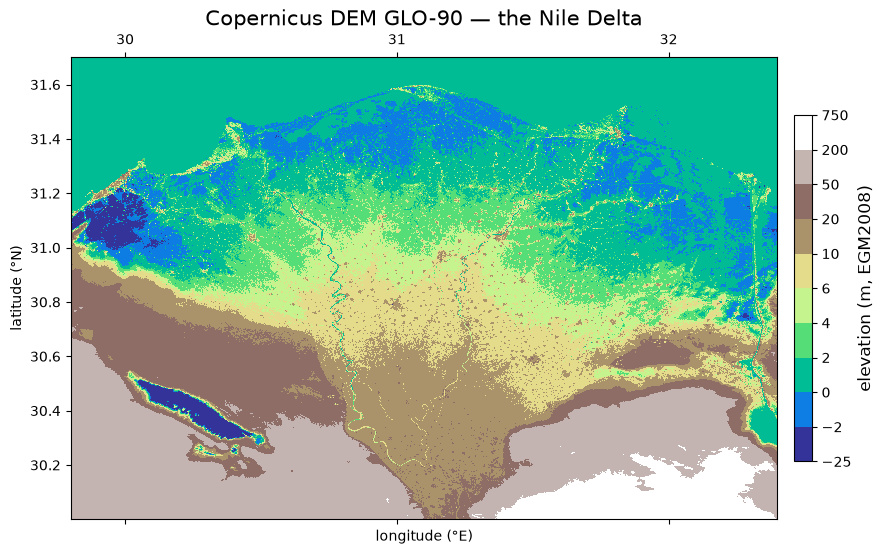

In [7]:
from pyramids.dataset.merge import merge_rasters

mosaic_path = delta_out / 'nile_delta_mosaic.tif'
merge_rasters(delta_paths, mosaic_path, no_data_value=-9999)

mosaic = Dataset.read_file(mosaic_path)
print(f'mosaic shape (y, x) : {mosaic.rows} x {mosaic.columns}')

delta = mosaic.crop(bbox=(29.8, 30.0, 32.4, 31.7), epsg=4326)
print(f'cropped shape (y, x): {delta.rows} x {delta.columns}')

glyph = delta.plot(
    cmap='terrain',
    color=ColorScaling.boundary(bounds=ELEVATION_BREAKS),
    colorbar=ColorBar(label=ELEVATION_LABEL),
    title='Copernicus DEM GLO-90 — the Nile Delta',
)
glyph.ax.set_xlabel(LON_LABEL)
glyph.ax.set_ylabel(LAT_LABEL)

## The delta as a surface — Digital-Earth's 3-D tier

Every map above is a colour ramp standing in for height. That is the only way a 2-D axes can show
elevation, and on a delta it is a poor one: almost the whole scene sits inside the first few metres, so the
class breaks have to crowd down there and the shape is carried entirely by colour.

`digitalearth.Scene3D` builds the raster into an actual surface mesh with PyVista, so height is height.
`z_exaggeration` is needed because the delta is genuinely flat — 382 km across with 730 m of relief, a ratio
of about 1:522, which at true scale is a sheet of paper. The vertical unit conversion is handled for us:
this raster is in degrees and the elevation is in metres, and `terrain` divides by the metres-per-degree so
the two axes are commensurate before the exaggeration is applied.

**One still, not a fly-through.** `Scene3D` can also `orbit` the camera and write the sweep to a GIF, and it
is tempting here — but on this scene it would show nothing a single view does not. Rotation earns its keep
by revealing ground hidden behind relief, and this delta hides **0.00%** of its cells at every azimuth and
every camera angle; there is simply nothing to occlude. The orbit lives in the
[bathymetry shaded-relief notebook](../bathymetry/05_shaded_relief.ipynb) instead, over the Mid-Atlantic
Ridge, where the relief is 1:42 and a low pass genuinely does bring new seafloor into view.

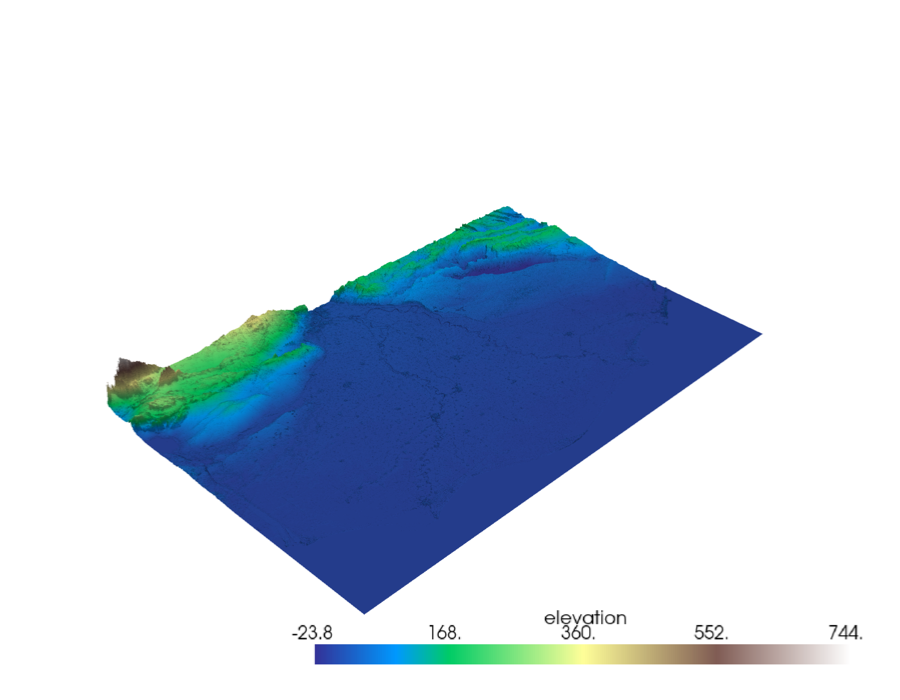

In [8]:
scene = Scene3D(off_screen=True, window_size=(900, 700))
scene.terrain(get_source(delta), z_exaggeration=40.0, cmap='terrain')
scene.plotter.view_isometric()

delta_3d = str(delta_out / 'nile_delta_3d.png')
scene.save(delta_3d)
scene.close()

display(Image(filename=delta_3d))

## What just happened — the account-free path

Every step above spoke to `s3://copernicus-dem-30m` and
`s3://copernicus-dem-90m` **anonymously**: no `~/.aws/credentials`, no
AWS profile, no environment variable, no signer. Copernicus DEM is the
only globally-consistent DEM reachable through `earthlens` without an
account, which is the entire justification for the `dem` backend.